# 04 Modeling

This notebook builds predictive models for workforce outcomes using the cleaned Stack Overflow 2025 survey data.

The first model predicts job satisfaction using learning pathway flags, experience, salary, education, AI attitudes, and workplace characteristics.

The second model predicts whether a respondent considered or transitioned into a new career or industry.

These models are predictive, not causal. They can show which variables are useful for prediction, but they do not prove that any learning pathway causes higher satisfaction or career change consideration.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv("../data/processed/stackoverflow_2025_project_cleaned.csv")

df.shape

(49191, 32)

## Model 1: Predicting Job Satisfaction

The first model predicts `JobSat`, a 0–10 job satisfaction score. This is a regression problem because the target is numeric.

The goal is not to perfectly predict every respondent's job satisfaction, but to test whether learning pathways and workforce characteristics contain useful predictive signal.

In [4]:
learning_features = [
    "learned_online_courses",
    "learned_school",
    "learned_bootcamp",
    "learned_ai",
    "learned_docs",
    "learned_on_job",
    "learned_books",
    "learned_videos"
]

numeric_features = [
    "YearsCode_clean",
    "WorkExp_clean",
    "log_salary"
]

categorical_features = [
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "AISelect",
    "AIThreat"
]

features = learning_features + numeric_features + categorical_features

target = "JobSat"

In [5]:
model_df = df[features + [target]].copy()

# Drop rows where the outcome is missing.
model_df = model_df.dropna(subset=[target])

model_df.shape

(26670, 17)

In [6]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("binary", binary_transformer, learning_features)
    ]
)

In [8]:
# Linear Regression baseline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

linear_mae, linear_rmse, linear_r2

(1.4685486988518648, np.float64(1.9429177333790872), 0.04914309198912725)

In [9]:
# results table
regression_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.468549,1.942918,0.049143


In [10]:
# Random Forest Regressor 

rf_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_regressor.fit(X_train, y_train)

rf_preds = rf_regressor.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

rf_mae, rf_rmse, rf_r2

(1.4735166257157346, np.float64(1.9534218990844925), 0.03883389799934467)

In [11]:
# Updated results table

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.468549,1.942918,0.049143
1,Random Forest Regressor,1.473517,1.953422,0.038834


## Job Satisfaction Model Interpretation

The linear regression model slightly outperformed the random forest regressor. The linear regression model had an MAE of about 1.47, meaning its predictions were off by roughly 1.47 job satisfaction points on a 0–10 scale on average.

The R² value was about 0.049, meaning the model explained approximately 4.9% of the variation in job satisfaction. This suggests that learning pathways, experience, salary, education, AI attitudes, and selected workplace characteristics contain some predictive signal, but they do not strongly predict job satisfaction by themselves.

This is not necessarily a failed model. Job satisfaction is likely influenced by many factors not fully captured in the survey, such as manager quality, team culture, workload, mission fit, burnout, and promotion opportunities.

## Feature Expansion Check

In [12]:
raw_df = pd.read_csv("../data/raw/results2025.csv", low_memory=False)

raw_df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

In [13]:
keywords = [
    "Job",
    "Work",
    "Remote",
    "Org",
    "AI",
    "Learn",
    "Dev",
    "Industry",
    "Tools",
    "Frustration",
    "Professional",
    "Comp",
    "Years"
]

for keyword in keywords:
    matches = [col for col in raw_df.columns if keyword.lower() in col.lower()]
    print(f"\n{keyword}:")
    print(matches)


Job:
['JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'JobSat']

Work:
['WorkExp', 'RemoteWork', 'ToolCountWork', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'DevEnvsHaveWorkedWith', 'DevEnvsWantToWorkWith', 'SOTagsHaveWorkedWith', 'SOTagsWantToWorkWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith']

Remote:
['RemoteWork']

Org:
['OrgSize']

AI:
['MainBranch', 'LearnCodeAI', 'AILearnHow', 'AIThreat', 'AIModelsChoice', 'AIModelsHaveWorkedWith', 

In [14]:
# Quick Numeric Correlation Check

numeric_check_cols = [
    "JobSat",
    "YearsCode_clean",
    "WorkExp_clean",
    "ConvertedCompYearly",
    "log_salary",
    "career_change_considered"
]

df[numeric_check_cols].corr(numeric_only=True)["JobSat"].sort_values(ascending=False)

JobSat                      1.000000
WorkExp_clean               0.105288
YearsCode_clean             0.093895
log_salary                  0.067154
ConvertedCompYearly         0.023568
career_change_considered   -0.272650
Name: JobSat, dtype: float64

In [15]:
# Categorical variables by average JobSat

categorical_check_cols = [
    "RemoteWork",
    "OrgSize",
    "EdLevel",
    "AISelect",
    "AIThreat",
    "DevType",
   
]

for col in categorical_check_cols:
    print("\n", col)
    display(
        df.groupby(col)["JobSat"]
        .agg(["count", "mean", "median"])
        .query("count >= 100")
        .sort_values("mean", ascending=False)
        .head(8)
    )


 RemoteWork


,count,mean,median
RemoteWork,,,
"Your choice (very flexible, you can come in when you want or just as needed)",2848,7.426966,8.0
Remote,7908,7.323849,8.0
"Hybrid (some in-person, leans heavy to flexibility)",4046,7.207365,8.0
Missing,3873,7.113865,8.0
"Hybrid (some remote, leans heavy to in-person)",4499,7.082240,7.0
In-person,3496,6.988272,7.0



 OrgSize


,count,mean,median
OrgSize,,,
"Just me - I am a freelancer, sole proprietor, etc.",865,7.565318,8.0
Less than 20 employees,3901,7.346065,8.0
20 to 99 employees,4816,7.224460,7.0
100 to 499 employees,4266,7.210502,8.0
"5,000 to 9,999 employees",1015,7.193103,7.0
500 to 999 employees,1655,7.166767,7.0
"1,000 to 4,999 employees",2734,7.136430,7.0
I don’t know,444,7.132883,7.0



 EdLevel


...

,count,mean,median
AISelect,,,
"Yes, I use AI tools daily",12599,7.289547,8.0
"Yes, I use AI tools weekly",4353,7.142890,7.0
"No, and I don't plan to",3643,7.138073,8.0
"No, but I plan to soon",1135,7.110132,8.0
"Yes, I use AI tools monthly or infrequently",3188,7.109473,7.0
Missing,1752,7.079338,7.0



 AIThreat


,count,mean,median
AIThreat,,,
Missing,134,7.708955,8.0
No,17076,7.404427,8.0
I'm not sure,5583,6.992298,7.0
Yes,3877,6.594532,7.0



 DevType


,count,mean,median
DevType,,,
"Founder, technology or otherwise",235,8.382979,9.0
"Senior executive (C-suite, VP, etc.)",273,8.150183,8.0
Cybersecurity or InfoSec professional,113,7.601770,8.0
Applied scientist,109,7.550459,8.0
"Architect, software or solutions",1865,7.542091,8.0
"Developer, game or graphics",301,7.368771,8.0
Engineering manager,595,7.368067,8.0
Academic researcher,285,7.361404,8.0


In [16]:
categorical_features_expanded = [
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "AISelect",
    "AIThreat",
    "DevType"
]

features_expanded = learning_features + numeric_features + categorical_features_expanded

model_df_expanded = df[features_expanded + ["JobSat"]].copy()
model_df_expanded = model_df_expanded.dropna(subset=["JobSat"])

X_expanded = model_df_expanded[features_expanded]
y_expanded = model_df_expanded["JobSat"]

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)

preprocessor_expanded = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features_expanded),
        ("binary", binary_transformer, learning_features)
    ]
)

expanded_linear = Pipeline(steps=[
    ("preprocessor", preprocessor_expanded),
    ("model", LinearRegression())
])

expanded_linear.fit(X_train_exp, y_train_exp)

expanded_preds = expanded_linear.predict(X_test_exp)

expanded_mae = mean_absolute_error(y_test_exp, expanded_preds)
expanded_rmse = np.sqrt(mean_squared_error(y_test_exp, expanded_preds))
expanded_r2 = r2_score(y_test_exp, expanded_preds)

expanded_mae, expanded_rmse, expanded_r2

(1.4640760947759923, np.float64(1.9357522366561812), 0.05614369533281327)

In [17]:
regression_results_expanded = pd.DataFrame({
    "Model": ["Original Linear Regression", "Expanded Linear Regression"],
    "MAE": [linear_mae, expanded_mae],
    "RMSE": [linear_rmse, expanded_rmse],
    "R2": [linear_r2, expanded_r2]
})

regression_results_expanded

,Model,MAE,RMSE,R2
0,Original Linear Regression,1.468549,1.942918,0.049143
1,Expanded Linear Regression,1.464076,1.935752,0.056144


## Expanded Regression Model Interpretation

Adding `DevType` to the regression model slightly improved performance. The expanded linear regression model had a lower MAE and RMSE than the original model, and R² increased from approximately 0.049 to 0.056.

This means the expanded model explained about 5.6% of the variation in job satisfaction, compared with about 4.9% in the original model. The improvement suggests that developer role type adds some predictive information, but the overall explanatory power remains limited.

This supports the conclusion that job satisfaction is difficult to predict from learning pathways and broad workforce characteristics alone. The available variables contain some signal, but much of job satisfaction likely depends on factors not captured in this survey, such as team culture, manager quality, workload, burnout, mission fit, and promotion opportunity.

# Part 2: Predicting Career Change Consideration

This section builds classification models to predict whether a respondent considered or transitioned into a new career or industry in the past year.

The target variable is `career_change_considered`.

This is a classification problem because the outcome is binary:

- 0 = did not consider or transition
- 1 = considered or transitioned

As with the regression model, this is predictive rather than causal. The model can identify patterns associated with career change consideration, but it does not prove that any specific feature causes someone to consider changing careers.

In [18]:
# Check target column balance in data
df["career_change_considered"].value_counts(dropna=False)

career_change_considered
1.0    19322
0.0    16205
NaN    13664
Name: count, dtype: int64

In [19]:
df["career_change_considered"].value_counts(normalize=True, dropna=True) * 100

career_change_considered
1.0    54.386804
0.0    45.613196
Name: proportion, dtype: float64

The target variable is fairly balanced among respondents who answered the question, which makes it reasonable to use accuracy along with precision, recall, F1, and ROC-AUC.

In [20]:
# Set up classification data using same features as regression model
classification_target = "career_change_considered"

classification_df = df[features + [classification_target]].copy()

# Drop rows where the outcome is missing.
classification_df = classification_df.dropna(subset=[classification_target])

classification_df.shape

(35527, 17)

In [21]:

X = classification_df[features]
y = classification_df[classification_target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# I used stratify=y because this is a classification problem. 
# It preserves the proportion of each target class in the training and testing sets,
#  making both sets more representative of the full dataset.

In [22]:
# Logistic Regression Baseline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

In [23]:
log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)
log_auc = roc_auc_score(y_test, log_probs)

log_accuracy, log_precision, log_recall, log_f1, log_auc

(0.5835913312693498,
 0.601889338731444,
 0.6923673997412678,
 0.643965828420166,
 0.6042238572494314)

In [24]:
# Random Forest Classifier
rf_classifier = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ))
])

rf_classifier.fit(X_train, y_train)

rf_preds = rf_classifier.predict(X_test)
rf_probs = rf_classifier.predict_proba(X_test)[:, 1]

In [25]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc

(0.5917534477905995,
 0.5976103685702714,
 0.7635187580853816,
 0.6704532545723049,
 0.6115266358066701)

In [26]:
# Results table
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1": [log_f1, rf_f1],
    "ROC_AUC": [log_auc, rf_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.583591,0.601889,0.692367,0.643966,0.604224
1,Random Forest Classifier,0.591753,0.597610,0.763519,0.670453,0.611527


In [27]:
# Confusion Matrix

# Starting with Regression

confusion_matrix(y_test, log_preds)

log_cm = confusion_matrix(y_test, log_preds)

log_cm_df = pd.DataFrame(
    log_cm,
    index=["Actual 0: No change considered", "Actual 1: Considered/transitioned"],
    columns=["Predicted 0", "Predicted 1"]
)

log_cm_df

,Predicted 0,Predicted 1
Actual 0: No change considered,1471,1770
Actual 1: Considered/transitioned,1189,2676


In [28]:
# Confusion Matrix for Random Forest

rf_cm = confusion_matrix(y_test, rf_preds)

rf_cm_df = pd.DataFrame(
    rf_cm,
    index=["Actual 0: No change considered", "Actual 1: Considered/transitioned"],
    columns=["Predicted 0", "Predicted 1"]
)

rf_cm_df

,Predicted 0,Predicted 1
Actual 0: No change considered,1254,1987
Actual 1: Considered/transitioned,914,2951


## Career Change Classification Model Interpretation

The random forest classifier performed slightly better than the logistic regression model overall. It had a higher accuracy, recall, F1 score, and ROC-AUC.

The strongest improvement was recall. The random forest correctly identified about 76% of respondents who considered or transitioned into a new career or industry, compared with about 69% for logistic regression. This suggests the random forest was better at finding the positive class.

However, the random forest also had slightly lower precision, meaning it produced more false positives. In plain language, it was more aggressive about predicting career change consideration.

The ROC-AUC values for both models were around 0.60 to 0.61. This means the models performed better than random guessing, but they were not strong classifiers. These results suggest that learning pathways, experience, salary, education, AI attitudes, and workplace characteristics contain some predictive signal, but they are not enough to confidently predict career change consideration at the individual level.

For workforce-development purposes, this model is more useful for identifying broad patterns than for labeling individuals as likely to change careers.

## Confusion Matrix Interpretation

The logistic regression model correctly identified 2,676 respondents who considered or transitioned into a new career or industry, while missing 1,189. It also incorrectly classified 1,770 respondents as having considered or transitioned when they had not.

The random forest classifier identified more of the actual career-change-consideration cases, correctly classifying 2,951 respondents in that group and missing only 914. However, it also produced more false positives, incorrectly classifying 1,987 respondents as having considered or transitioned when they had not.

Overall, the random forest had stronger recall for the career-change-consideration group, while the logistic regression model was somewhat less aggressive. In a workforce-development setting, higher recall may be useful if the goal is to identify broad patterns associated with career mobility. However, the false positives show why this model should not be interpreted as a definitive individual-level risk prediction.

# New Model Stage

## Turn classifier into bands instead of yes/no  
High, medium, and low probability


In [29]:
test_band_df = X_test.copy()
test_band_df["actual"] = y_test.values

test_band_df["predicted_probability"] = rf_classifier.predict_proba(X_test)[:, 1]

test_band_df["probability_band"] = pd.cut(
    test_band_df["predicted_probability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Lower", "Middle", "Higher"]
)

test_band_df["probability_band"].value_counts()

test_band_summary = (
    test_band_df
    .groupby("probability_band")["actual"]
    .agg(["count", "mean"])
)

test_band_summary["actual_percent_considered"] = (
    test_band_summary["mean"] * 100
).round(1)

test_band_summary



C:\Users\patri\AppData\Local\Temp\ipykernel_20188\1275567123.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("probability_band")["actual"]


,count,mean,actual_percent_considered
probability_band,,,
Lower,354,0.305085,30.5
Middle,5176,0.524923,52.5
Higher,1576,0.659898,66.0


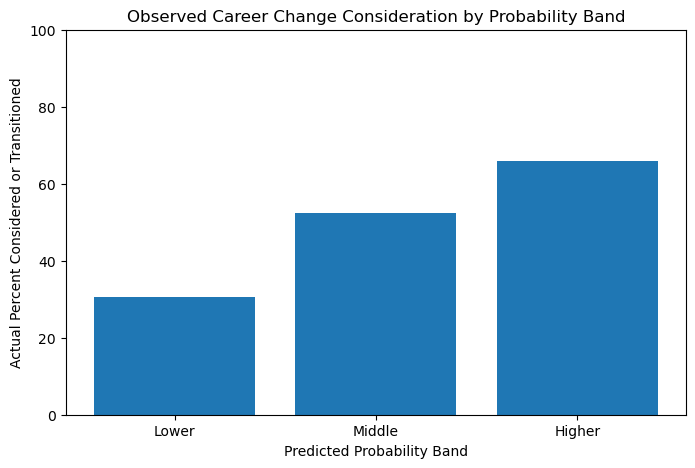

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(
    test_band_summary.index.astype(str),
    test_band_summary["actual_percent_considered"]
)

plt.xlabel("Predicted Probability Band")
plt.ylabel("Actual Percent Considered or Transitioned")
plt.title("Observed Career Change Consideration by Probability Band")
plt.ylim(0, 100)
plt.show()

In [31]:
# This version had data leakage
# classification_df["predicted_probability"] = rf_classifier.predict_proba(
#     classification_df[features]
# )[:, 1]

# classification_df["probability_band"] = pd.cut(
#     classification_df["predicted_probability"],
#     bins=[0, 0.4, 0.6, 1.0],
#     labels=["Lower", "Middle", "Higher"]
# )

# classification_df["probability_band"].value_counts()

In [32]:
# band_summary = (
#     classification_df
#     .groupby("probability_band")["career_change_considered"]
#     .agg(["count", "mean"])
# )

# band_summary["actual_percent_considered"] = (
#     band_summary["mean"] * 100
# ).round(1)

# band_summary

In [33]:
# band_summary = (
#     classification_df
#     .groupby("probability_band")["career_change_considered"]
#     .agg(["count", "mean"])
# )

# band_summary["actual_percent_considered"] = (
#     band_summary["mean"] * 100
# ).round(1)

# band_summary

In [34]:
# plt.figure(figsize=(8, 5))
# plt.bar(
#     band_summary.index.astype(str),
#     band_summary["actual_percent_considered"]
# )

# plt.xlabel("Predicted Probability Band")
# plt.ylabel("Actual Percent Considered or Transitioned")
# plt.title("Observed Career Change Consideration by Predicted Probability Band")
# plt.ylim(0, 100)
# plt.show()

## Probability Band Interpretation

The probability bands were evaluated on the held-out test set, meaning the model was tested on data that was not used during training.

The probability bands show a useful group-level pattern. Respondents in the lower-probability band had an observed career change consideration rate of 30.5%. Respondents in the middle band had an observed rate of 52.5%. Respondents in the higher-probability band had an observed rate of 66.0%.

This means the model is not just guessing randomly. It is sorting respondents into groups with different observed rates of career change consideration. The separation is not strong enough to support confident individual-level prediction, but it is useful for workforce pattern recognition.

For workforce-development purposes, the model is best understood as a tool for identifying broad patterns associated with career change consideration, not as a tool for labeling individual people.

# Modeling Summary
Regression:
Job satisfaction is hard to predict from these variables.

Classification:
Career change consideration is only moderately predictable as yes/no,
but probability bands show clear separation across lower, middle, and higher likelihood groups.

## Random Forest Feature Importance

In [35]:
# Get feature names after preprocessing
feature_names = rf_classifier.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances from the random forest model
importances = rf_classifier.named_steps["model"].feature_importances_

# Put them into a dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
2,num__log_salary,0.115594
0,num__YearsCode_clean,0.110497
1,num__WorkExp_clean,0.104592
36,cat__AIThreat_No,0.079733
37,cat__AIThreat_Yes,0.074007
38,binary__learned_online_courses,0.041894
10,cat__EdLevel_Secondary school (e.g. American h...,0.024430
41,binary__learned_ai,0.023734
42,binary__learned_docs,0.022246
34,cat__AIThreat_I'm not sure,0.020527


In [36]:
feature_importance["clean_feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("binary__", "", regex=False)
)

feature_importance.head(20)

,feature,importance,clean_feature
2,num__log_salary,0.115594,log_salary
0,num__YearsCode_clean,0.110497,YearsCode_clean
1,num__WorkExp_clean,0.104592,WorkExp_clean
36,cat__AIThreat_No,0.079733,AIThreat_No
37,cat__AIThreat_Yes,0.074007,AIThreat_Yes
38,binary__learned_online_courses,0.041894,learned_online_courses
10,cat__EdLevel_Secondary school (e.g. American h...,0.024430,EdLevel_Secondary school (e.g. American high s...
41,binary__learned_ai,0.023734,learned_ai
42,binary__learned_docs,0.022246,learned_docs
34,cat__AIThreat_I'm not sure,0.020527,AIThreat_I'm not sure


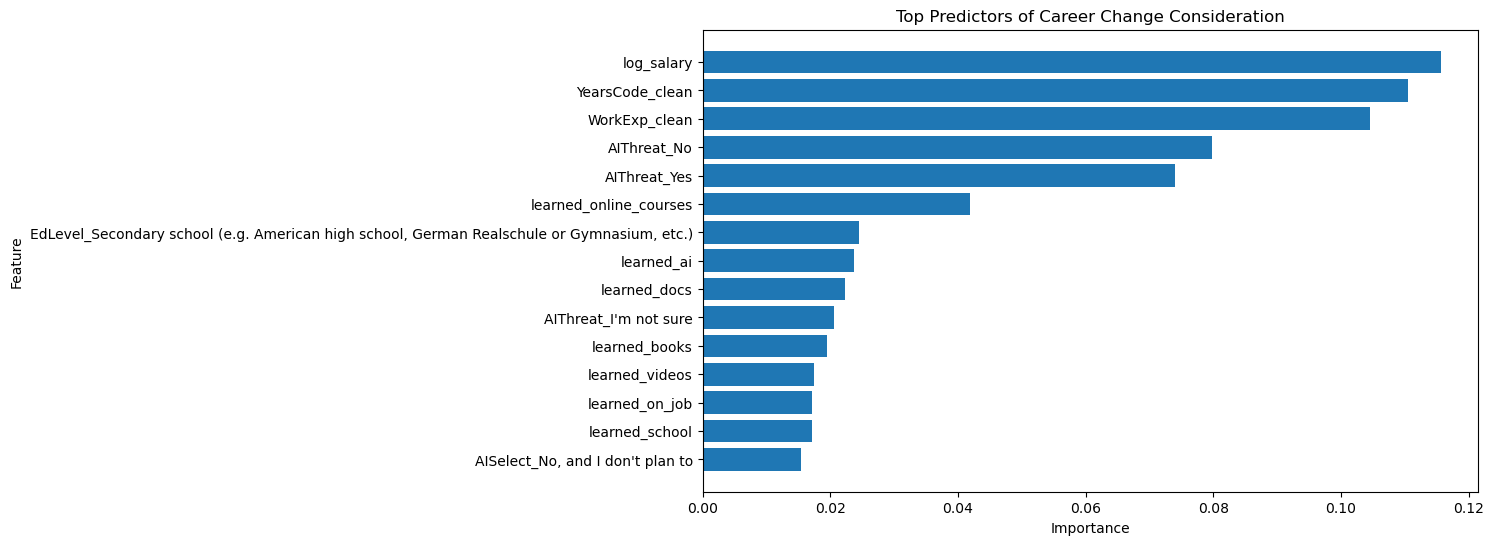

In [37]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["clean_feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Predictors of Career Change Consideration")
plt.show()

In [38]:
def assign_feature_group(feature):
    if "learned_" in feature:
        return "Learning pathways"
    elif "YearsCode" in feature or "WorkExp" in feature or "salary" in feature:
        return "Experience and compensation"
    elif "AISelect" in feature or "AIThreat" in feature:
        return "AI use and attitudes"
    elif "RemoteWork" in feature or "OrgSize" in feature:
        return "Work setting"
    elif "EdLevel" in feature:
        return "Education"
    else:
        return "Other"

feature_importance["feature_group"] = feature_importance["clean_feature"].apply(assign_feature_group)

group_importance = (
    feature_importance
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

group_importance

feature_group
Experience and compensation    0.330683
AI use and attitudes           0.245780
Learning pathways              0.173510
Work setting                   0.162093
Education                      0.087933
Name: importance, dtype: float64

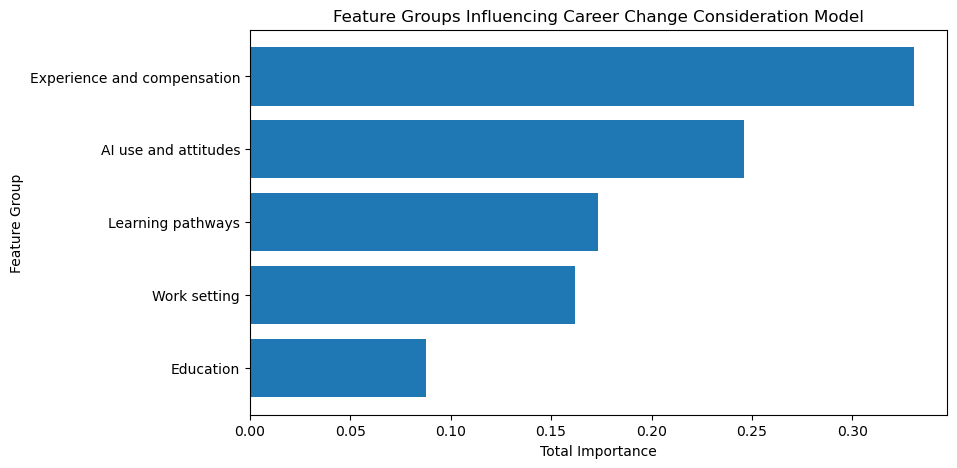

In [39]:
group_importance_plot = group_importance.sort_values()

plt.figure(figsize=(9, 5))
plt.barh(group_importance_plot.index, group_importance_plot.values)
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")
plt.title("Feature Groups Influencing Career Change Consideration Model")
plt.show()